In [1]:
# 1. Import modules
from typing import Literal
from pydantic import BaseModel
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings, ChatOllama
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState

In [2]:
# 2, Load Documents
loader = PyPDFLoader("./documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
# 3. Split Documents
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)

chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [4]:
# 5. Embedding Model

embeddings = OllamaEmbeddings(model="embeddinggemma:300m")

In [5]:
# 6. Vector_store in memory only

vectorstore = Chroma(
    collection_name="rag_conditional",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

retriever = vectorstore.as_retriever(search_kwargs={"k":4})
print("Vector store is ready")

Vector store is ready


In [6]:
# 6. LLM
llm = ChatOllama(model = "llama3.2:3b")

In [7]:
# 7. State Definaltion

class AgenticRAGState(MessagesState):

    query:str
    retrieved_docs:list[Document] | None
    context:str
    generation:str
    needs_retrieval:bool

In [8]:
# 8. Structured output schema for the routing decision

class RouteDecision(BaseModel):

    needs_retrieval: bool


In [9]:
# 9. Route question node

def route_question(state:AgenticRAGState)->dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system","Classify whether the following question requires retrieving information from a specialize document, or can be answer from your own general knowledge"),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [11]:
# 10. Retrive node

def retrieve(state:AgenticRAGState)->dict:
    docs = retriever. invoke(state["query"])

    if docs:
        context = "\n\n".join(doc.page_content for doc in docs)

    return {"retrieved_docs": docs, "context":context}    
 

In [12]:
# 11. Generation node

def generate(state:AgenticRAGState)->dict:

    query = state["query"]
    context = state.get("context") or ""

    if context:    
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        
        response = (prompt_template | llm).invoke({"context": context, "query": query})
    
    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [13]:
# 12. # Routing function: maps needs_retrieval bool to the next node name
def route_after_classification(state: AgenticRAGState) -> Literal["retrieve", "generate"]:
    return "retrieve" if state["needs_retrieval"] else "generate"

In [14]:
# 13. # Graph Definition
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("needs_retrieval", route_question)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "needs_retrieval")
graph_builder.add_conditional_edges("needs_retrieval", route_after_classification)
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [15]:
graph = graph_builder.compile()

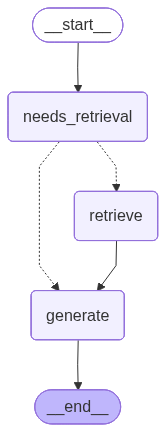

In [16]:
graph

In [17]:
# Query 1: domain-specific (should trigger retrieval)
domain_query = "What does the report say about EV adoption trajectories and oil demand displacement?"

result_domain = graph.invoke({"query": domain_query, "messages": []})

In [18]:
# Output: Query 1 (domain-specific)
print("=== QUERY 1 (domain-specific) ===")
print(f"Query          : {domain_query}")
print(f"needs_retrieval: {result_domain['needs_retrieval']}")
retrieved = result_domain.get("retrieved_docs") or []
print(f"Retrieved docs : {len(retrieved)} docs")
print(f"\nGeneration:\n{result_domain['generation']}")

=== QUERY 1 (domain-specific) ===
Query          : What does the report say about EV adoption trajectories and oil demand displacement?
needs_retrieval: True
Retrieved docs : 4 docs

Generation:
According to the report, projecting oil demand displacement from EV adoption requires integrating three distinct analytical layers: 

1. The annual sales trajectory for new EVs
2. The retirement rate of the existing ICE fleet
3. The average annual mileage and fuel economy of the vehicles being displaced.

The report also mentions that with a global new vehicle sales of roughly 90 million units per year and average vehicle lifetimes of 15 to 20 years in developed markets — and often longer in developing markets — complete fleet electrification cannot occur in less than two to three decades.


In [19]:
# Section 9 — Query 2: general knowledge (should skip retrieval)
general_query = "What is the capital of India?"

result_general = graph.invoke({"query": general_query, "messages": []})

In [20]:
# Output: Query 2 (general knowledge)
print("=== QUERY 2 (general knowledge) ===")
print(f"Query          : {general_query}")
print(f"needs_retrieval: {result_general['needs_retrieval']}")
print(f"Retrieved docs : {result_general.get('retrieved_docs')}")
print(f"\nGeneration:\n{result_general['generation']}")

=== QUERY 2 (general knowledge) ===
Query          : What is the capital of India?
needs_retrieval: False
Retrieved docs : None

Generation:
The capital of India is New Delhi.
